# 12.2 · Bounding rectangles and shape approximations

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain bounding rectangles and shape approximations using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[07 · Geometric Transformations](../../07-geometric-transformations/README.md), [11 · Morphological Image Processing](../../11-morphological-image-processing/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

A contour traces a region boundary. Once a segmentation mask is available, contours convert pixels into geometric measurements: area, perimeter, enclosing boxes, convex hulls and polygon approximations. The measurement is only as reliable as the mask and scale calibration.

## 2. Intuition

An axis-aligned bounding box follows image axes; a rotated minimum-area rectangle follows object orientation. Polygon approximation removes points while limiting boundary deviation. Too large an epsilon turns curved shapes into crude polygons, while too small an epsilon preserves noise.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 12
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
C=4\pi A/P^2
$$

C is circularity, A region area and P perimeter in consistent units. A continuous circle of radius 3 has area 9π and perimeter 6π, yielding C=1. Digitized contours generally differ from the continuous ideal.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
radius = 3.0
area = np.pi * radius**2
perimeter = 2 * np.pi * radius
circularity = 4 * np.pi * area / perimeter**2
assert np.isclose(circularity, 1)
print(circularity)

1.0


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

OpenCV finds boundaries in the synthetic mask, measures each contour and overlays approximations and rotated boxes. Shape rules use measured values and expose ambiguous cases.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def contours(lesson, seed, amount):
    mask = shapes()
    view = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)
    outlines, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    areas = []
    vertices = []
    for contour in outlines:
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, 0.02 * amount * perimeter, True)
        areas.append(float(area))
        vertices.append(len(approx))
        if lesson == 0:
            cv2.drawContours(view, [approx], -1, (255, 80, 30), 2)
        elif lesson == 1:
            box = np.int32(cv2.boxPoints(cv2.minAreaRect(contour)))
            cv2.drawContours(view, [box], -1, (255, 80, 30), 1)
        else:
            cv2.drawContours(view, [cv2.convexHull(contour)], -1, (255, 80, 30), 2)
    return Result(
        "12 · Contour area, perimeter and shape approximation",
        {"Binary shapes": mask, "Measured boundaries": view},
        metrics={"contour_count": len(outlines), "areas_px2": areas, "polygon_vertices": vertices},
        notes="Contour polygon area differs from the count of foreground pixels; no physical length is known without calibration.",
    )

{
  "contour_count": 3,
  "areas_px2": [
    396.0,
    752.0,
    621.0
  ],
  "polygon_vertices": [
    3,
    8,
    4
  ]
}
Contour polygon area differs from the count of foreground pixels; no physical length is known without calibration.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import components

display(Code(inspect.getsource(components), language="python"))

def components(mask):
    """4-connected foreground labels using a queue flood-fill, background=0."""
    mask = np.asarray(mask, bool)
    labels = np.zeros(mask.shape, np.int32)
    count = 0
    for y, x in zip(*np.nonzero(mask), strict=True):
        if labels[y, x]:
            continue
        count += 1
        labels[y, x] = count
        queue = deque([(y, x)])
        while queue:
            yy, xx = queue.popleft()
            for dy, dx in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                yn, xn = yy + dy, xx + dx
                if 0 <= yn < mask.shape[0] and 0 <= xn < mask.shape[1]:
                    if mask[yn, xn] and not labels[yn, xn]:
                        labels[yn, xn] = count
                        queue.append((yn, xn))
    return labels, count

## 8. Experiment

Rotate a rectangle and compare its axis-aligned box area with its minimum-area box. Add holes and inspect contour hierarchy.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "contour_count": 3,
    "areas_px2": [
      396.0,
      752.0,
      621.0
    ],
    "polygon_vertices": [
      3,
      8,
      4
    ]
  },
  "second_seed": {
    "contour_count": 3,
    "areas_px2": [
      396.0,
      752.0,
      621.0
    ],
    "polygon_vertices": [
      3,
      8,
      4
    ]
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

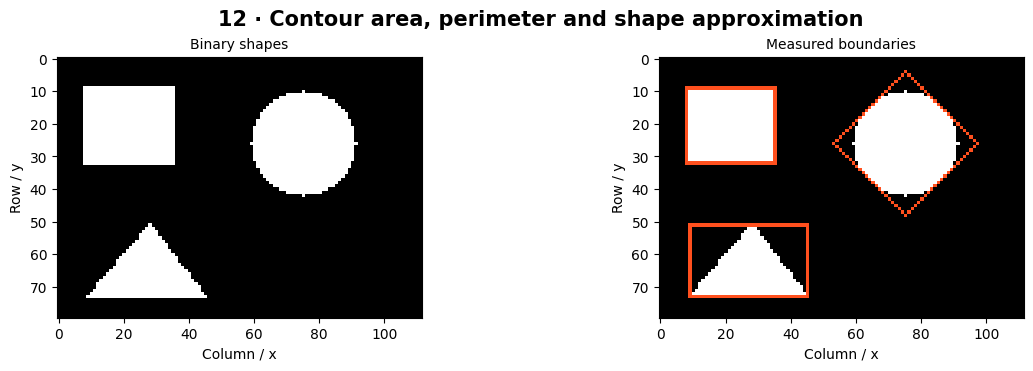

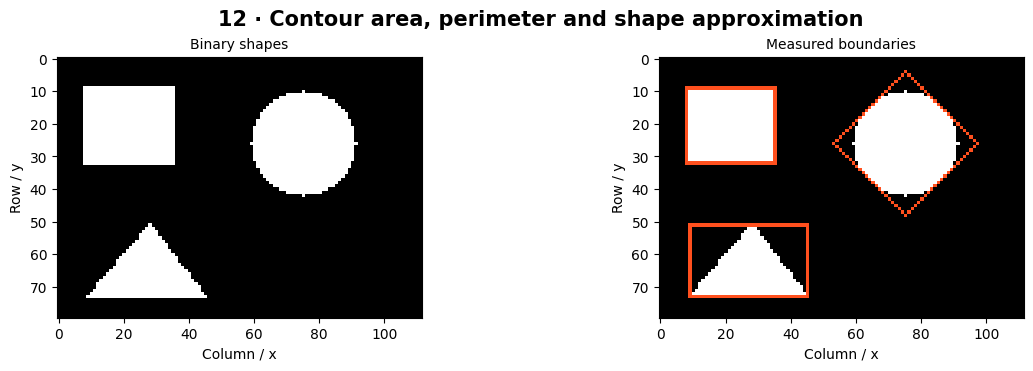

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Shape Measurement System**. Measure image shapes and distinguish pixels from physical units. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Perspective changes apparent size. A fixed pixels-per-millimeter ratio cannot measure arbitrary depths.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Rotate a rectangle and compare its axis-aligned box area with its minimum-area box. Add holes and inspect contour hierarchy.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a shape measurement tool using a reference object on the same plane, and include uncertainty from boundary perturbations.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

An axis-aligned bounding box follows image axes; a rotated minimum-area rectangle follows object orientation. Polygon approximation removes points while limiting boundary deviation. Too large an epsilon turns curved shapes into crude polygons, while too small an epsilon preserves noise.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Convexity and calibrated dimensions** in this chapter.

[Primary reference](https://docs.opencv.org/4.x/d3/d05/tutorial_py_table_of_contents_contours.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)